# SurgeShield — Model Interpretation

**OSEMN stage: iNterpret (N)**

The final pipeline stage. It turns the trained artifacts into the real,
reported outputs that the Flask API and analytics UI consume. The reproducible
version is `interpret.py`; we import and run it here so the notebook reports
exactly what the script produces.

**Outputs** (all into `5_interpretation/`):
- `metrics.json` — the **single source of truth** for best-model metrics
- `confusion_matrix.json`, `roc_data.json`, `feature_importances.json`
- `figures/confusion_matrix.png`, `roc_curves.png`, `feature_importance.png`

`interpret.py` loads the **saved** best model + scaler + encoder and rebuilds
the *same* stratified 80/20 split used in training (`random_state=42`), so every
number corresponds to the genuine held-out test set.

## 1. Run interpretation

This evaluates the best model on the held-out test set, computes the confusion
matrix / ROC / feature importances, and writes the four JSON files and three
figures.

In [1]:
import json
import pandas as pd
from IPython.display import Image, display

import interpret

pd.set_option('display.max_columns', None)
interpret.main()

SurgeShield — model interpretation (iNterpret)
[ctx]  best model = Logistic Regression  test n = 2,000


[fig]  5_interpretation\figures\confusion_matrix.png


[fig]  5_interpretation\figures\roc_curves.png


[fig]  5_interpretation\figures\feature_importance.png
[shap] skipped (ModuleNotFoundError: No module named 'shap')
[json] 5_interpretation\metrics.json
[json] 5_interpretation\confusion_matrix.json
[json] 5_interpretation\roc_data.json
[json] 5_interpretation\feature_importances.json

Headline (held-out test):
  model=Logistic Regression  acc=0.5025  f1=0.5450  roc_auc=0.4984
Done. metrics.json is the single source of truth for the API + UI.


## 2. Metrics — the single source of truth

`metrics.json` is what `GET /model-info` returns and what the UI renders. These
are the real held-out test numbers — never hard-coded.

In [2]:
with open(interpret.HERE / 'metrics.json', encoding='utf-8') as f:
    metrics = json.load(f)
print('Best model :', metrics['best_model'])
print('Feature count (raw / encoded):', metrics['feature_count'], '/', metrics['feature_count_encoded'])
pd.Series(metrics['metrics']).round(4).to_frame('value')

Best model : Logistic Regression
Feature count (raw / encoded): 11 / 19


,value
accuracy,0.5025
precision,0.5068
recall,0.5895
f1,0.5450
roc_auc,0.4984


## 3. Confusion matrix

On the 2,000-row test set. With no signal, predictions split roughly evenly
regardless of the true label — the matrix is close to four equal quadrants.

TN=409  FP=580  FN=415  TP=596


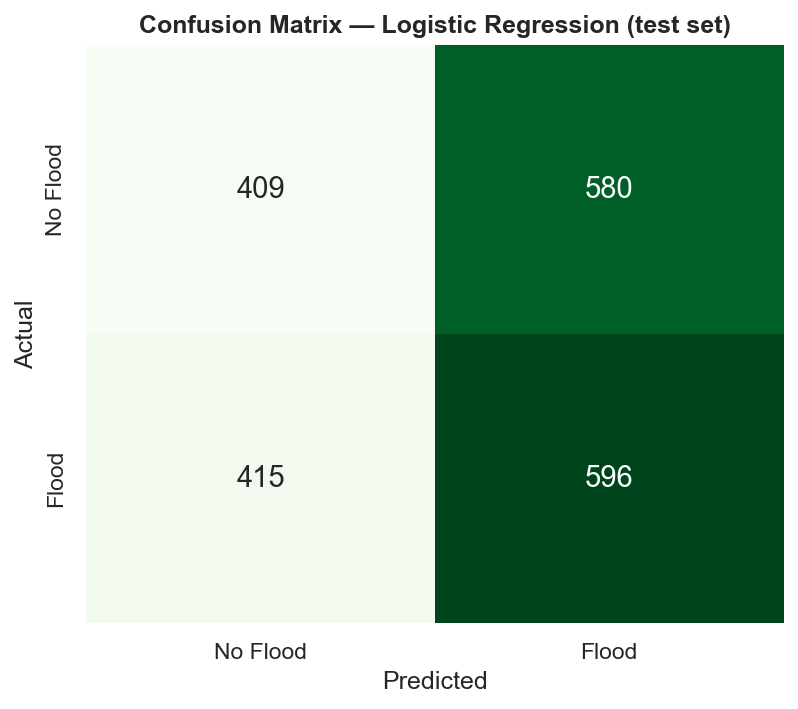

In [3]:
with open(interpret.HERE / 'confusion_matrix.json', encoding='utf-8') as f:
    cm = json.load(f)
print('TN={tn}  FP={fp}  FN={fn}  TP={tp}'.format(**cm))
display(Image(filename=str(interpret.FIG_DIR / 'confusion_matrix.png')))

## 4. ROC curves

All three models evaluated on the same test set. Every curve sits on the chance
diagonal (AUC ≈ 0.50) — the decisive visual of the no-signal finding.

Logistic Regression    AUC = 0.4984
Random Forest          AUC = 0.4943
XGBoost                AUC = 0.4913


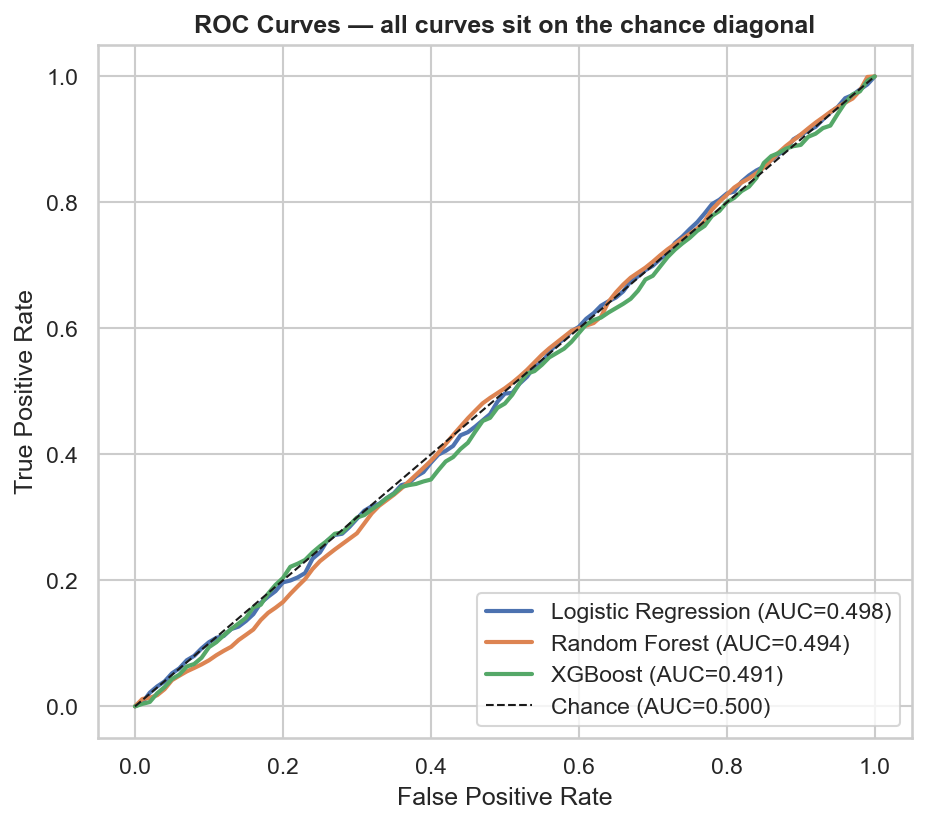

In [4]:
with open(interpret.HERE / 'roc_data.json', encoding='utf-8') as f:
    roc = json.load(f)
for name, d in roc['models'].items():
    print(f"{name:<22} AUC = {d['auc']:.4f}")
display(Image(filename=str(interpret.FIG_DIR / 'roc_curves.png')))

## 5. Feature importance

For the best model (Logistic Regression, so importance = coefficient
magnitude, aggregated back to the 11 original features). All magnitudes are
tiny — no feature carries weight, consistent with every earlier diagnostic.

Importance type: logistic_coefficient


,feature,importance,signed
0,Historical Floods,0.076368,0.076368
1,Humidity,0.061088,0.061088
2,Infrastructure,0.030338,-0.030338
3,Temperature,0.029850,-0.029850
4,Water Level,0.021982,-0.021982
5,Elevation,0.021873,-0.021873
6,Rainfall,0.010430,-0.010430
7,River Discharge,0.009626,-0.009626
8,Population Density,0.004797,-0.004797
9,Land Cover,0.000492,0.000492


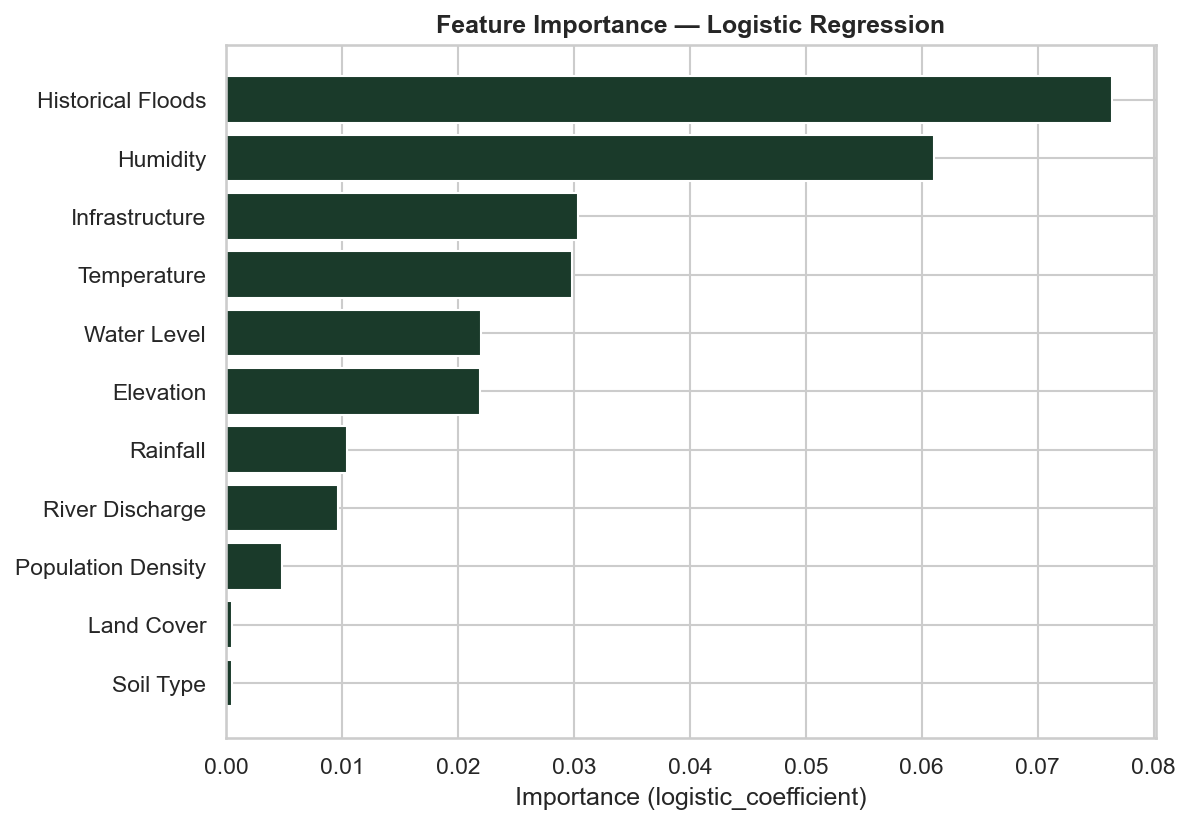

In [5]:
with open(interpret.HERE / 'feature_importances.json', encoding='utf-8') as f:
    fi = json.load(f)
print('Importance type:', fi['type'])
display(pd.DataFrame(fi['importances']))
display(Image(filename=str(interpret.FIG_DIR / 'feature_importance.png')))

## Conclusion

The interpretation stage confirms, on the held-out test set, what every prior
stage found: the model performs at chance (ROC-AUC ≈ 0.50), the confusion matrix
is near-uniform, and no feature carries meaningful weight.

`metrics.json` now serves as the single source of truth: `GET /model-info` reads
it directly, and `GET /analytics` serves `confusion_matrix.json`, `roc_data.json`,
and `feature_importances.json` to the UI. Every reported number is the real,
measured value.

This completes the OSEMN pipeline (Obtain → Scrub → Explore → Model →
iNterpret). The deliverable is a complete, honest, deployable system — ready to
consume any properly-signalled dataset without code changes.